In [1]:
import pandas as pd
from sqlalchemy import create_engine, text
import redshift_connector
import numpy as np
import warnings
warnings.filterwarnings('ignore')
import warnings
import matplotlib.pyplot as plt
import seaborn as sns
from prophet import Prophet
from prophet.plot import plot_plotly
from prophet.plot import add_changepoints_to_plot
from prophet.diagnostics import cross_validation, performance_metrics

In [2]:
# Enter Redshift connection details
conn_args = {
    'host': 'cm-mks-helix-cluster-1.cgv0wa0jntot.us-west-2.redshift.amazonaws.com',
    'database': 'cm_sandbox_4',
    'port': 5439,
    'user': 'tribalvw',
    'password': 'R3$h!ft35263e3f!LxLc'
        }
# Establish connection
conn = redshift_connector.connect(**conn_args)

# Direct read (No S3 staging)
query = "SELECT * FROM tribal_vw.Models_Advanced_Forecasting"
input_df = pd.read_sql(query, conn) 

# Access the data directly as a Pandas DataFrame
data = input_df
conn.close()

In [3]:
data

,week_start,total_records_weekly,model,visits,purchase_intents,quality_arrivals,retailer_leads,natural_search_visits,paid_search_visits,direct_visits,paid_social_visits,email_visits,other_channel_visits
0,2024-05-27,7,Polo,15002,3504,5914,86,5983,5735,2174,670,380,13
1,2024-05-13,7,Polo,16836,4166,6518,125,6371,5731,2357,1403,928,4
2,2024-06-10,7,Polo,15312,3494,6052,63,6042,5582,2381,812,419,68
3,2024-10-14,7,Polo,14324,3074,4792,57,4977,6201,1708,1178,432,64
4,2024-11-11,7,Polo,13067,2793,4488,106,4575,5224,1857,1405,286,31
...,...,...,...,...,...,...,...,...,...,...,...,...,...
991,2023-07-31,7,Golf,26110,3584,9432,0,13399,8895,2701,0,736,132
992,2023-06-05,7,Golf,21763,3044,7923,0,13714,5064,2100,0,408,86
993,2023-08-14,7,ID.4,11219,748,1826,58,5681,2597,1825,0,155,16
994,2023-09-18,7,ID.4,12498,937,1959,70,7097,2179,2131,0,150,28


In [6]:
polo_df = data[data['model'] == 'Polo']

In [7]:
polo_df_sorted = polo_df.sort_values(by='week_start', ascending=True)
polo_df_sorted.style

,week_start,total_records_weekly,model,visits,purchase_intents,quality_arrivals,retailer_leads,natural_search_visits,paid_search_visits,direct_visits,paid_social_visits,email_visits,other_channel_visits
41,2022-12-26,1,Polo,1277,221,530,0,1074,42,145,0,1,0
36,2023-01-02,7,Polo,13008,2453,5221,82,10736,318,1502,0,139,37
37,2023-01-09,7,Polo,14421,2375,5593,59,8243,3857,1597,0,132,61
7,2023-01-16,7,Polo,14950,2510,5861,53,7812,4904,1699,0,112,47
367,2023-01-23,7,Polo,15624,2688,6232,62,8218,5343,1761,0,74,73
359,2023-01-30,7,Polo,16018,2628,6141,41,7664,5770,1819,0,63,49
349,2023-02-06,7,Polo,17728,2726,6385,66,7284,7132,1938,0,454,82
29,2023-02-13,7,Polo,17880,2601,6058,62,6963,8051,1592,0,747,85
8,2023-02-20,7,Polo,18249,2746,6061,66,7111,8626,1592,0,641,100
862,2023-02-27,7,Polo,16873,2721,6019,103,7726,5787,1559,0,607,59


In [5]:

polo_df.info()
print((polo_df == 0).sum())
polo_df.isna().sum()

NameError: name 'polo_df' is not defined

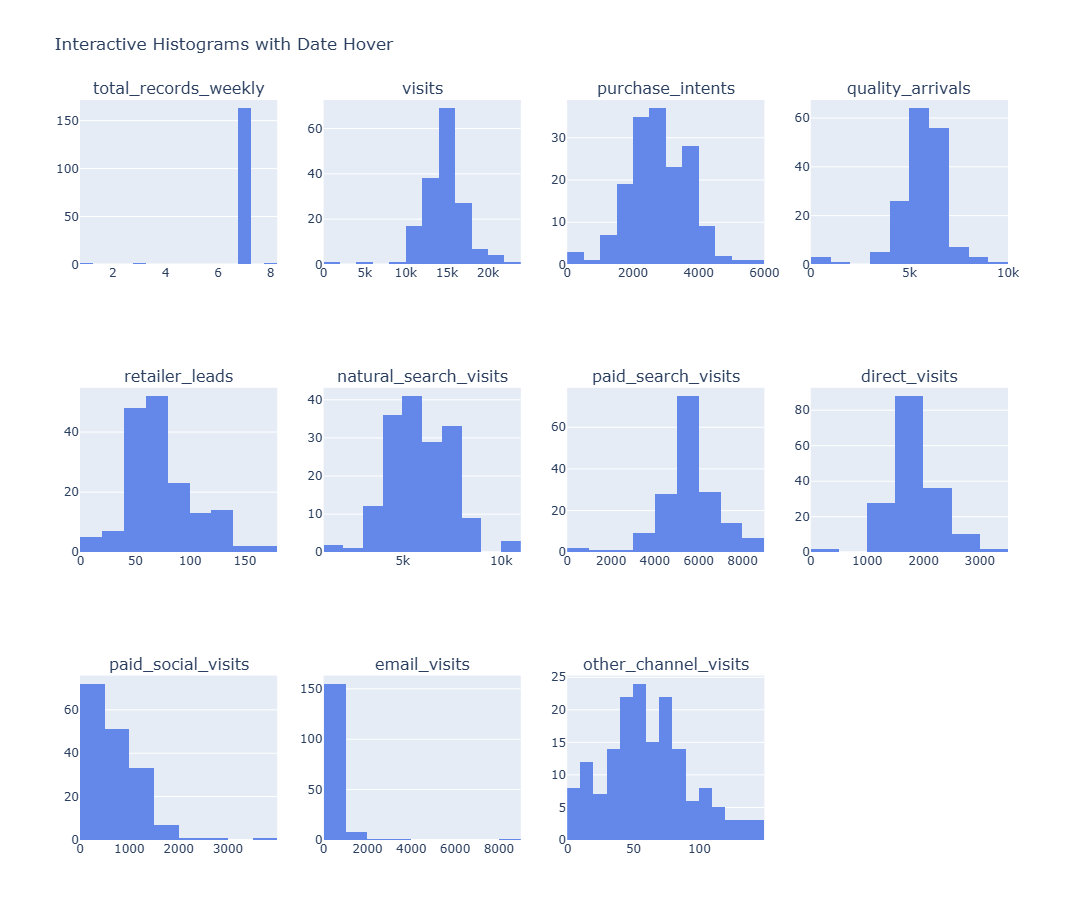

In [11]:
import plotly.express as px
from plotly.subplots import make_subplots
import plotly.graph_objects as go
import math
import pandas as pd

# 1.Convert to datetime 
polo_df_sorted['week_start'] = pd.to_datetime(polo_df_sorted['week_start'])

# 2. Create the formatted date string for the hover display
polo_df_sorted['week_start_str'] = polo_df_sorted['week_start'].dt.strftime('%Y-%m-%d')

# Identifying numerical columns
numerical_cols = [col for col in polo_df_sorted.select_dtypes(include=['number']).columns if col != 'week_start']
num_cols = len(numerical_cols)
rows = math.ceil(num_cols / 4)
cols = 4

fig = make_subplots(rows=rows, cols=cols, subplot_titles=numerical_cols)

for i, col in enumerate(numerical_cols, 1):
    row_idx = math.ceil(i / cols)
    col_idx = (i - 1) % cols + 1

    fig.add_trace(
        go.Histogram(
            x=polo_df[col],
            # 3. Use 'customdata' to pass the original dates to the binned trace
            customdata=polo_df_sorted['week_start_str'],
            nbinsx=15,
            name=col,
            # 4. Reference customdata in the template
            marker_color='#6488EA', 
            hovertemplate=(
                '<b>Week Start:</b> %{customdata}<br>'
                '<b>Value:</b> %{x}<br>'
                '<b>Count:</b> %{y}<extra></extra>'
            )
        ),
        row=row_idx,
        col=col_idx
    )

fig.update_layout(
    title_text='Interactive Histograms with Date Hover',
    height=300 * rows,
    width=1200,
    showlegend=False,
    template='plotly',
    # FIX: Set the hover label font color to white
    hoverlabel=dict(
        font_color="white",
        font_size=13,
        bgcolor="#2c3e50"  # Dark background makes white text pop
    )
)

fig.show()


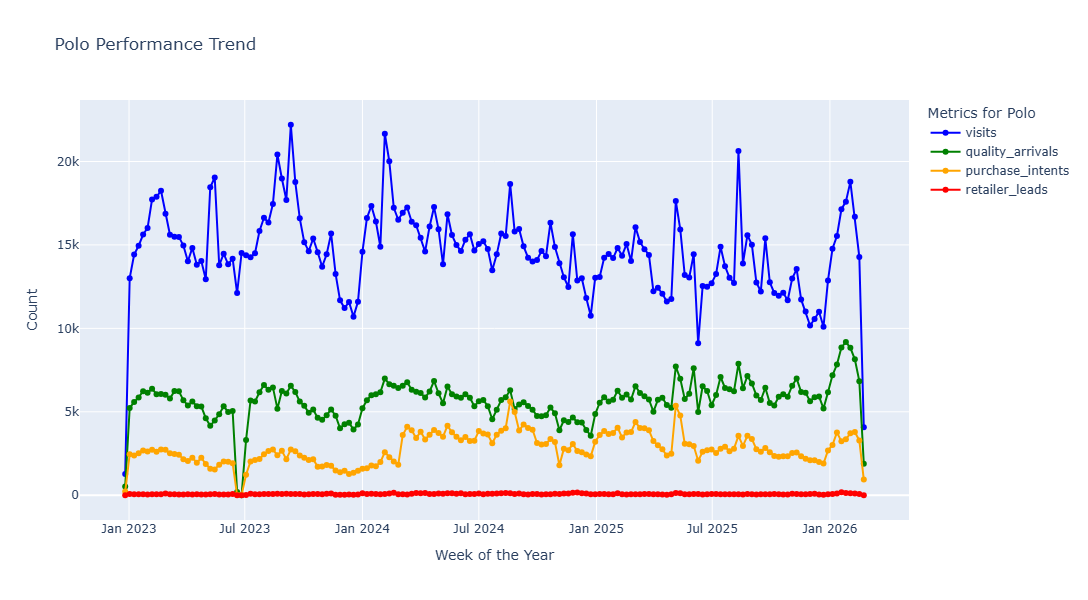

In [9]:
import plotly.express as px

# 1. Sort the DataFrame (ensure week_start is your x-axis)
polo_df_sorted = polo_df.sort_values(by='week_start', ascending=True)

# 2. Plot multiple columns by passing a list to 'y'
fig = px.line(
    polo_df_sorted,
    x='week_start',
    y=['visits', 'quality_arrivals', 'purchase_intents', 'retailer_leads'],  # List of columns
    title='Polo Performance Trend',
    markers=True,
    height=600,
    # Define custom colors for each column
    color_discrete_map={
        "visits": "blue",
        "quality_arrivals": "green",
        "purchase_intents": "orange",
        "retailer_leads": "red"
    }
)

# 3. Customizing labels and layout
fig.update_layout(
    xaxis_title='Week of the Year',
    yaxis_title='Count',
    legend_title='Metrics for Polo',
    xaxis=dict(showgrid=True),
    yaxis=dict(showgrid=True)
)

# 4. Display the figure
fig.show()


In [8]:
# 1. Select only numeric columns to avoid string errors
polo_df_numeric = polo_df.select_dtypes(include=['number'])

# Calculate Q1 (25th percentile) and Q3 (75th percentile)
Q1 = polo_df_numeric.quantile(0.25)
Q3 = polo_df_numeric.quantile(0.75)
IQR = Q3 - Q1

# Define bounds
lower_bound = Q1 - 1.6 * IQR
upper_bound = Q3 + 1.6 * IQR

# Count outliers per column
outliers_count = ((polo_df_numeric < lower_bound) | (polo_df_numeric > upper_bound)).sum()
print(outliers_count)


total_records_weekly      3
visits                    5
purchase_intents          3
quality_arrivals          9
retailer_leads           11
natural_search_visits     0
paid_search_visits        7
direct_visits             4
paid_social_visits        1
email_visits              8
other_channel_visits      1
dtype: int64


In [9]:
# 3. Identify all outliers across the entire numeric dataframe
outlier_mask = (polo_df_numeric < lower_bound) | (polo_df_numeric > upper_bound)

# 4. Extract outliers and their corresponding week_start
# We "stack" the data to get a row for every outlier found
outliers_stacked = polo_df_numeric[outlier_mask].stack().reset_index()
outliers_stacked.columns = ['index', 'column_name', 'outlier_value']

# 5. Map the original week_start dates back using the index
outliers_stacked['week_start'] = outliers_stacked['index'].map(polo_df['week_start'])

# 6. Final Clean Table
final_outliers = outliers_stacked[['week_start', 'column_name', 'outlier_value']]

print("Outliers across all columns:")
print(final_outliers)


Outliers across all columns:
    week_start           column_name  outlier_value
0   2025-08-11                visits        20630.0
1   2025-08-11          email_visits         8042.0
2   2023-02-20    paid_search_visits         8626.0
3   2024-02-19        retailer_leads          157.0
4   2025-08-18          email_visits         1361.0
5   2026-02-09      quality_arrivals         8145.0
6   2024-12-02        retailer_leads          161.0
7   2023-01-02    paid_search_visits          318.0
8   2023-09-11                visits        22202.0
9   2023-09-11         direct_visits         3242.0
10  2025-12-29  total_records_weekly            8.0
11  2022-12-26  total_records_weekly            1.0
12  2022-12-26                visits         1277.0
13  2022-12-26      quality_arrivals          530.0
14  2022-12-26        retailer_leads            0.0
15  2022-12-26    paid_search_visits           42.0
16  2022-12-26         direct_visits          145.0
17  2023-08-21          email_visit

In [10]:
# Remove all rows on date 26Dec 2022 beacuse of its outlier nature
import pandas as pd

# 1. Ensure the week_start column is in datetime format
polo_df['week_start'] = pd.to_datetime(polo_df['week_start'])

# 2. Filter out the specific date (keep all rows NOT equal to 2022-12-26)
# Use the ISO format 'YYYY-MM-DD' for reliable matching
polo_df = polo_df[polo_df['week_start'] != '2022-12-26']

# Optional: Verify the date is gone
print(f"Remaining rows: {len(polo_df)}")


Remaining rows: 165


In [11]:
polo_df_sorted = polo_df.sort_values(by='week_start', ascending=True)

In [12]:
# Removing 0 value from quality_arrivals on 26 June 2023 and replacing it with NAN so that prophet will extrapolate it.
polo_df_sorted = polo_df.sort_values(by='week_start', ascending=True)
# 1. Ensure the date column is in datetime format
polo_df_sorted['week_start'] = pd.to_datetime(polo_df_sorted['week_start'])

# 2. Define your condition: date is 26 June 2023 AND quality_arrivals is 0
mask = (polo_df_sorted['week_start'] == '2023-06-26') & (polo_df_sorted['quality_arrivals'] == 0)

# 3. Use .loc to target the specific column and rows to replace with NaN
polo_df_sorted.loc[mask, 'quality_arrivals'] = np.nan

# Optional: verify the change
print(polo_df_sorted[polo_df_sorted['week_start'] == '2023-06-26'])


    week_start  total_records_weekly model  visits  purchase_intents  \
858 2023-06-26                     7  Polo   14517                23   

     quality_arrivals  retailer_leads  natural_search_visits  \
858               NaN               1                   7666   

     paid_search_visits  direct_visits  paid_social_visits  email_visits  \
858                5381           2189                   0           110   

     other_channel_visits  
858                    20  


## Model 0: Simple forecast without outlier date: 26 Dec 2022 removed and 0 value in QAs on 26 June 2023 converted to NAN.

Processing model for: visits


19:03:29 - cmdstanpy - INFO - Chain [1] start processing
19:03:29 - cmdstanpy - INFO - Chain [1] done processing


Processing model for: quality_arrivals


19:03:29 - cmdstanpy - INFO - Chain [1] start processing
19:03:30 - cmdstanpy - INFO - Chain [1] done processing


Processing model for: purchase_intents


19:03:30 - cmdstanpy - INFO - Chain [1] start processing
19:03:30 - cmdstanpy - INFO - Chain [1] done processing
19:03:30 - cmdstanpy - INFO - Chain [1] start processing


Processing model for: retailer_leads


19:03:31 - cmdstanpy - INFO - Chain [1] done processing


IndexError: index 3 is out of bounds for axis 0 with size 3

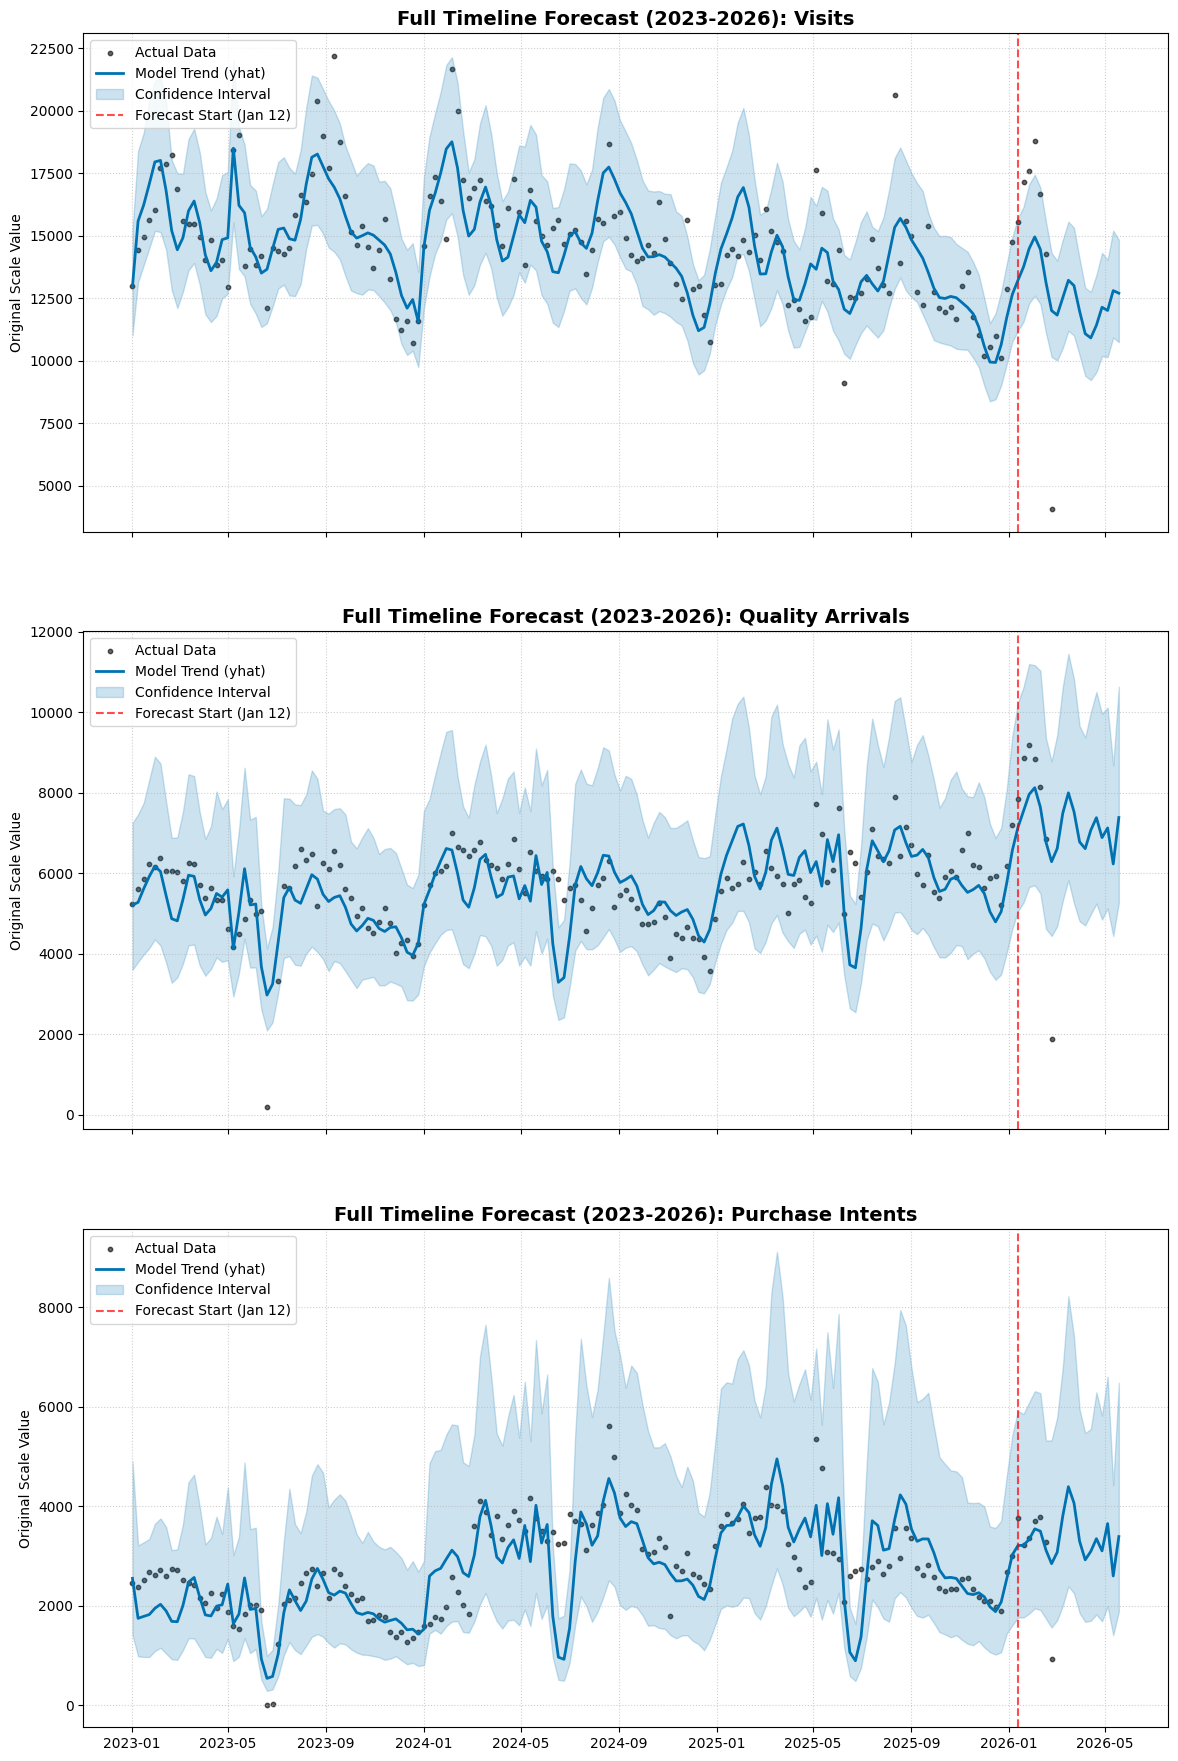

In [13]:
# Model 0: Simple Model with data as it is and NOT replacing outliers with NANs
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from prophet import Prophet

# 1. Data Preparation
polo_df_sorted['ds'] = pd.to_datetime(polo_df_sorted['week_start'])
kpis = ['visits', 'quality_arrivals', 'purchase_intents', 'retailer_leads']#, 'retailer_leads']

# Apply Log Transformation (log(1+x)) for all KPIs
for kpi in kpis:
    polo_df_sorted[f'log_{kpi}'] = np.log1p(polo_df_sorted[kpi])

# 2. Iterative Model Training and Full Timeline Forecasting
final_forecasts = {}
mape_scores = {}

for kpi in kpis:
    print(f"Processing model for: {kpi}")
    
    # Initialize Model with UK Holidays
    m = Prophet(seasonality_mode='additive')
    m.add_country_holidays(country_name='UK')
    
    # Fit on all available historical data (up to Jan 19, 2026)
    m.fit(polo_df_sorted[['ds', f'log_{kpi}']].rename(columns={f'log_{kpi}': 'y'}))
    
    # 3. Create a dataframe covering BOTH History and 3 Months Future
    # 'periods=12' for 3 months (16 weeks) forward from 19 Jan 2026
    full_timeline_df = m.make_future_dataframe(periods=12, freq='W-MON')
    
    # Generate Predictions for the entire period (Dec 2022 to May 2026)
    forecast = m.predict(full_timeline_df)
    
    # 4. Inverse Transformation (e^y - 1) back to original scale
    for col in ['yhat', 'yhat_lower', 'yhat_upper']:
        forecast[col] = np.expm1(forecast[col])
    
    # 5. Calculate MAPE (on historical scale only)
    # Join historical actuals with the corresponding historical predictions
    performance_df = forecast.set_index('ds').join(polo_df_sorted.set_index('ds')[[kpi]], how='inner')
    mape = np.mean(np.abs((performance_df[kpi] - performance_df['yhat']) / performance_df[kpi])) * 100
    mape_scores[kpi] = mape
    
    # Store the full forecast for plotting
    final_forecasts[kpi] = forecast

# 6. Output MAPE Results
#print("\n--- Model Performance (MAPE) ---")
#for kpi, score in mape_scores.items():
#    print(f"{kpi}: {score:.2f}%")

# 7. Visualization: Full Timeline (Actuals vs Predicted)
fig, axes = plt.subplots(3, 1, figsize=(14, 22), sharex=True)

for i, kpi in enumerate(kpis):
    ax = axes[i]
    forecast_df = final_forecasts[kpi]
    
    # Plot Historical Actuals as black dots
    ax.scatter(polo_df_sorted['ds'], polo_df_sorted[kpi], color='black', label='Actual Data', s=10, alpha=0.6)
    
    # Plot Continuous Model Trend Line (History + Future)
    ax.plot(forecast_df['ds'], forecast_df['yhat'], color='#0072B2', label='Model Trend (yhat)', linewidth=2)
    
    # Plot Confidence Intervals (Shaded Area)
    ax.fill_between(forecast_df['ds'], forecast_df['yhat_lower'], forecast_df['yhat_upper'], 
                    color='#0072B2', alpha=0.2, label='Confidence Interval')
    
    # Add a vertical line to mark the start of the 2026 Forecast
    ax.axvline(pd.to_datetime('2026-01-12'), color='red', linestyle='--', alpha=0.7, label='Forecast Start (Jan 12)')
    
    # Formatting
    ax.set_title(f'Full Timeline Forecast (2023-2026): {kpi.replace("_", " ").title()}', fontsize=14, fontweight='bold')
    ax.set_ylabel('Original Scale Value')
    ax.grid(True, linestyle=':', alpha=0.6)
    ax.legend(loc='upper left')

plt.xlabel('Year')
plt.tight_layout()
plt.show()


In [60]:
# Model 0: These df will shoe 172 rows as it is including forecasted data for 3 months: 160+12= 172 weeks
# Access the DataFrame for 'visits' only
visits_df = final_forecasts['visits']

# Access the DataFrame for 'quality_arrivals' only
quality_arrivals_df = final_forecasts['quality_arrivals']

# Access the DataFrame for 'purchase_intents' only
purchase_intents_df = final_forecasts['purchase_intents']


## Model 1: Genuine Outliers treated, Train-Test SPlit 3 months and on test unexposed data. Auto Grid Search with cross-val approach. Results:The MAPE for visits is: 9.20% The MAPE for purchase_intents is: 17.02% The MAPE for quality_arrivals is: 13.61%. 

In [47]:
# Model 1
import pandas as pd
import numpy as np
import itertools
from prophet import Prophet
from prophet.diagnostics import cross_validation, performance_metrics

# 1. Data Preparation & Log Transformation
polo_df_sorted['ds'] = pd.to_datetime(polo_df_sorted['week_start'])
kpis = ['visits', 'purchase_intents', 'quality_arrivals']

# Apply Log Transformation (log(1+x)) to handle potential zeros safely
for kpi in kpis:
    polo_df_sorted[f'log_{kpi}'] = np.log1p(polo_df_sorted[kpi])

# Train-Test Split (Last 3 months for testing)
split_date = polo_df_sorted['ds'].max() - pd.DateOffset(months=3)
train_full = polo_df_sorted[polo_df_sorted['ds'] <= split_date]
test_full = polo_df_sorted[polo_df_sorted['ds'] > split_date]

# 2. Holidays: Custom Events + UK Bank Holidays
#holidays_df = pd.DataFrame({
#    'holiday': 'one_off_event',
#    'ds': pd.to_datetime(['2023-05-15', '2024-11-20', '2025-06-10']),
#    'lower_window': 0,
#    'upper_window': 1,
#})

# 3. Grid Search Setup
param_grid = {  
    'changepoint_prior_scale': [0.001, 0.01, 0.1, 0.5],
    'seasonality_prior_scale': [0.01, 0.1, 1.0, 10.0],
    'holidays_prior_scale': [0.01, 0.1, 1.0, 10.0]
}
all_params = [dict(zip(param_grid.keys(), v)) for v in itertools.product(*param_grid.values())]

def tune_prophet(train_df, log_kpi_col):
    rmses = []
    df_kpi = train_df[['ds', log_kpi_col]].rename(columns={log_kpi_col: 'y'})
    
    for params in all_params:
        # Note: log transformation naturally models multiplicative effects, 
        # so seasonality_mode='additive' is typically best here
        m = Prophet(seasonality_mode='additive', **params)
        m.add_country_holidays(country_name='UK')
        m.fit(df_kpi)
        
        df_cv = cross_validation(m, initial='730 days', period='90 days', horizon='90 days')
        df_p = performance_metrics(df_cv, rolling_window=1)
        rmses.append(df_p['rmse'].values[0])
        
    return all_params[rmses.index(min(rmses))]

# 4. Iterative Execution & Inverse Transformation
forecasts = {}
best_params_storage = {}

for kpi in kpis:
    print(f"--- Processing {kpi} ---")
    log_col = f'log_{kpi}'
    
    # Grid Search on Training Data
    best_p = tune_prophet(train_full, log_col)
    best_params_storage[kpi] = best_p
    
    # Train Final Model
    m = Prophet(seasonality_mode='additive', **best_p)
    m.add_country_holidays(country_name='UK')
    m.fit(train_full[['ds', log_col]].rename(columns={log_col: 'y'}))
    
    # Forecast
    future = test_full[['ds']]
    forecast_log = m.predict(future)
    
    # Inverse Transformation (e^y - 1)
    for col in ['yhat', 'yhat_lower', 'yhat_upper']:
        forecast_log[col] = np.expm1(forecast_log[col])
    
    forecasts[kpi] = forecast_log

# 5. Output Parameters & Performance
for kpi in kpis:
    print(f"\nBest Params for {kpi}: {best_params_storage[kpi]}")
    actuals = test_full[kpi].values
    preds = forecasts[kpi]['yhat'].values
    mape = np.mean(np.abs((actuals - preds) / actuals)) * 100
    print(f"Final MAPE for {kpi}: {mape:.2f}%")


--- Processing visits ---


12:11:43 - cmdstanpy - INFO - Chain [1] start processing
12:11:43 - cmdstanpy - INFO - Chain [1] done processing
  0%|                                                                                            | 0/3 [00:00<?, ?it/s]12:11:44 - cmdstanpy - INFO - Chain [1] start processing
12:11:44 - cmdstanpy - INFO - Chain [1] done processing
 33%|████████████████████████████                                                        | 1/3 [00:01<00:02,  1.04s/it]12:11:45 - cmdstanpy - INFO - Chain [1] start processing
12:11:45 - cmdstanpy - INFO - Chain [1] done processing
 67%|████████████████████████████████████████████████████████                            | 2/3 [00:01<00:00,  1.43it/s]12:11:45 - cmdstanpy - INFO - Chain [1] start processing
12:11:45 - cmdstanpy - INFO - Chain [1] done processing
100%|████████████████████████████████████████████████████████████████████████████████████| 3/3 [00:01<00:00,  1.55it/s]
12:11:46 - cmdstanpy - INFO - Chain [1] start processing
12:11:46 - cmd

--- Processing purchase_intents ---


12:13:53 - cmdstanpy - INFO - Chain [1] start processing
12:13:53 - cmdstanpy - INFO - Chain [1] done processing
  0%|                                                                                            | 0/3 [00:00<?, ?it/s]12:13:54 - cmdstanpy - INFO - Chain [1] start processing
12:13:54 - cmdstanpy - INFO - Chain [1] done processing
 33%|████████████████████████████                                                        | 1/3 [00:00<00:00,  2.18it/s]12:13:54 - cmdstanpy - INFO - Chain [1] start processing
12:13:54 - cmdstanpy - INFO - Chain [1] done processing
 67%|████████████████████████████████████████████████████████                            | 2/3 [00:00<00:00,  2.20it/s]12:13:55 - cmdstanpy - INFO - Chain [1] start processing
12:13:55 - cmdstanpy - INFO - Chain [1] done processing
100%|████████████████████████████████████████████████████████████████████████████████████| 3/3 [00:01<00:00,  2.21it/s]
12:13:55 - cmdstanpy - INFO - Chain [1] start processing
12:13:55 - cmd

--- Processing quality_arrivals ---


12:15:52 - cmdstanpy - INFO - Chain [1] start processing
12:15:52 - cmdstanpy - INFO - Chain [1] done processing
  0%|                                                                                            | 0/3 [00:00<?, ?it/s]12:15:52 - cmdstanpy - INFO - Chain [1] start processing
12:15:52 - cmdstanpy - INFO - Chain [1] done processing
 33%|████████████████████████████                                                        | 1/3 [00:00<00:00,  2.21it/s]12:15:53 - cmdstanpy - INFO - Chain [1] start processing
12:15:53 - cmdstanpy - INFO - Chain [1] done processing
 67%|████████████████████████████████████████████████████████                            | 2/3 [00:00<00:00,  2.22it/s]12:15:53 - cmdstanpy - INFO - Chain [1] start processing
12:15:53 - cmdstanpy - INFO - Chain [1] done processing
100%|████████████████████████████████████████████████████████████████████████████████████| 3/3 [00:01<00:00,  2.23it/s]
12:15:53 - cmdstanpy - INFO - Chain [1] start processing
12:15:54 - cmd


Best Params for visits: {'changepoint_prior_scale': 0.01, 'seasonality_prior_scale': 0.01, 'holidays_prior_scale': 0.01}
Final MAPE for visits: 9.20%

Best Params for purchase_intents: {'changepoint_prior_scale': 0.5, 'seasonality_prior_scale': 0.01, 'holidays_prior_scale': 0.1}
Final MAPE for purchase_intents: 17.02%

Best Params for quality_arrivals: {'changepoint_prior_scale': 0.01, 'seasonality_prior_scale': 0.01, 'holidays_prior_scale': 1.0}
Final MAPE for quality_arrivals: 13.61%


In [48]:
# Model 1 Results
mape_results = {}

for kpi in kpis:
    # Extract actuals from the test set and predictions from the forecast
    actuals = test_full[kpi].values
    predictions = forecasts[kpi]['yhat'].values
    
    # Calculate MAPE: mean of (|actual - predicted| / actual) * 100
    # Note: We add a tiny epsilon to denominator to avoid division by zero if necessary
    mape = np.mean(np.abs((actuals - predictions) / actuals)) * 100
    mape_results[kpi] = mape

# Displaying the results
for kpi, score in mape_results.items():
    print(f"The MAPE for {kpi} is: {score:.2f}%")


The MAPE for visits is: 9.20%
The MAPE for purchase_intents is: 17.02%
The MAPE for quality_arrivals is: 13.61%


In [49]:
# Model 1 Forecasted Tables
import pandas as pd

# List to store the simplified DataFrames for each KPI
final_tables = {}

for kpi in kpis:
    # Get the specific columns from the existing forecasts dictionary
    df_result = forecasts[kpi][['ds', 'yhat', 'yhat_lower', 'yhat_upper']].copy()
    
    # Rename 'ds' back to 'week_start' for your reporting
    df_result = df_result.rename(columns={'ds': 'week_start'})
    
    # Add a column to identify the KPI if you plan to merge them later
    df_result['kpi'] = kpi
    
    final_tables[kpi] = df_result

# Example: Display the head of the 'visits' results
print(final_tables['visits'].head())

# Optional: Merge all 3 into one large "Master Forecast" DataFrame
master_forecast_df = pd.concat(final_tables.values(), ignore_index=True)


  week_start          yhat    yhat_lower    yhat_upper     kpi
0 2025-10-20  12646.942434  11383.881747  14124.298178  visits
1 2025-10-27  12589.473445  11241.867308  14015.734109  visits
2 2025-11-03  12223.927251  10954.484726  13789.648321  visits
3 2025-11-10  11805.529896  10651.666604  13162.752888  visits
4 2025-11-17  11536.393010  10334.675990  12906.023850  visits


## Model 2: Auto Grid Crossvalidation refreshed model for auto grid search on full data till 19 Jan 2026. With forecasted period of 12 weeks. Outliers treatment : 26 Dec 2022 removed. One 0 in QAs converted to NAN. MAPE for visits: 10.97%, MAPE for purchase_intents: 43.59%,  MAPE for quality_arrivals: 14.31%

In [70]:
polo_df_sorted = polo_df.sort_values(by='week_start', ascending=True)

In [71]:
# Removing 0 value from quality_arrivals on 26 June 2023 and replacing it with NAN so that prophet will extrapolate it.

# 1. Ensure the date column is in datetime format
polo_df_sorted['week_start'] = pd.to_datetime(polo_df_sorted['week_start'])

# 2. Define your condition: date is 26 June 2023 AND quality_arrivals is 0
mask = (polo_df_sorted['week_start'] == '2023-06-26') & (polo_df_sorted['quality_arrivals'] == 0)

# 3. Use .loc to target the specific column and rows to replace with NaN
polo_df_sorted.loc[mask, 'quality_arrivals'] = np.nan

# Optional: verify the change
print(polo_df_sorted[polo_df_sorted['week_start'] == '2023-06-26'])


    week_start  total_records_weekly model  visits  purchase_intents  \
593 2023-06-26                     7  Polo   14517                23   

     quality_arrivals  retailer_leads  natural_search_visits  \
593               NaN             175                   7666   

     paid_search_visits  direct_visits  paid_social_visits  email_visits  \
593                5381           2189                   0           110   

     other_channel_visits week_start_str  
593                    20     2023-06-26  


In [72]:
# Model 2
import pandas as pd
import numpy as np
import itertools
from prophet import Prophet
from prophet.diagnostics import cross_validation, performance_metrics

# 1. Data Preparation (Full Dataset)
# Ensure data ends at the week of 19 Jan 2026
polo_df_sorted['ds'] = pd.to_datetime(polo_df_sorted['week_start'])
# golf_df_full = golf_df_sorted[golf_df_sorted['ds'] <= '2026-01-19'].copy()
kpis = ['visits', 'purchase_intents', 'quality_arrivals']

# Apply log transformation for stability in business metrics
for kpi in kpis:
    polo_df_sorted[f'log_{kpi}'] = np.log1p(polo_df_sorted[kpi])

# 2. Custom One-off Events + UK Bank Holidays
#holidays_df = pd.DataFrame({
#    'holiday': 'one_off_event',
#    'ds': pd.to_datetime(['2023-05-15', '2024-11-20', '2025-06-10']),
#    'lower_window': 0,
#    'upper_window': 1,
#})

# 3. Grid Search Setup for Hyperparameter Tuning
param_grid = {  
    'changepoint_prior_scale': [0.01, 0.05, 0.1, 0.5],
    'seasonality_prior_scale': [0.1, 1.0, 10.0],
    'holidays_prior_scale': [0.1, 1.0, 10.0]
}
all_params = [dict(zip(param_grid.keys(), v)) for v in itertools.product(*param_grid.values())]

def perform_grid_search(df, log_kpi_col):
    rmses = []
    df_tuning = df[['ds', log_kpi_col]].rename(columns={log_kpi_col: 'y'})
    
    for params in all_params:
        m = Prophet(seasonality_mode='additive', **params)
        m.add_country_holidays(country_name='UK')
        m.fit(df_tuning)
        
        # Cross-validation uses the history to simulate forecasting performance
        # initial: training window, horizon: forecast window to test
        df_cv = cross_validation(m, initial='730 days', period='90 days', horizon='90 days')
        df_p = performance_metrics(df_cv, rolling_window=1)
        rmses.append(df_p['rmse'].values[0])
        
    return all_params[rmses.index(min(rmses))]

# 4. Iterative Model Training and 16-Week Forecast
best_params_results = {}
final_forecast_list = []

# Define the explicit 16-week forecast period starting Jan 19, 2026
future_df_dates = pd.DataFrame({
    'ds': pd.date_range(start='2026-01-19', periods=12, freq='W-MON')
})

for kpi in kpis:
    print(f"Running grid search for: {kpi}...")
    log_col = f'log_{kpi}'
    
    # Identify best params using full available history
    best_p = perform_grid_search(polo_df_sorted, log_col)
    best_params_results[kpi] = best_p
    
    # Train the final model with best params on the full history
    m_final = Prophet(seasonality_mode='additive', **best_p)
    m_final.add_country_holidays(country_name='UK')
    m_final.fit(polo_df_sorted[['ds', log_col]].rename(columns={log_col: 'y'}))
    
    # Predict 16 weeks forward
    forecast = m_final.predict(future_df_dates)
    
    # Inverse transform results (e^y - 1) back to original scale
    for col in ['yhat', 'yhat_lower', 'yhat_upper']:
        forecast[col] = np.expm1(forecast[col])
    
    # Formatting the output
    forecast = forecast.rename(columns={'ds': 'week_start'})
    forecast_clean = forecast[['week_start', 'yhat', 'yhat_lower', 'yhat_upper']].copy()
    forecast_clean['KPI'] = kpi
    final_forecast_list.append(forecast_clean)

# 5. Output Results
print("\n--- OPTIMAL HYPERPARAMETERS FOUND ---")
for kpi, params in best_params_results.items():
    print(f"{kpi}: {params}")

# Final Combined Forecast DataFrame
final_output_df = pd.concat(final_forecast_list, ignore_index=True)
print("\n--- 12-WEEK FORECAST (Starting 19 Jan 2026) ---")
print(final_output_df.head(20))


Running grid search for: visits...


13:24:22 - cmdstanpy - INFO - Chain [1] start processing
13:24:23 - cmdstanpy - INFO - Chain [1] done processing
  0%|                                                                                            | 0/4 [00:00<?, ?it/s]13:24:23 - cmdstanpy - INFO - Chain [1] start processing
13:24:23 - cmdstanpy - INFO - Chain [1] done processing
 25%|█████████████████████                                                               | 1/4 [00:00<00:02,  1.02it/s]13:24:24 - cmdstanpy - INFO - Chain [1] start processing
13:24:24 - cmdstanpy - INFO - Chain [1] done processing
 50%|██████████████████████████████████████████                                          | 2/4 [00:01<00:01,  1.07it/s]13:24:25 - cmdstanpy - INFO - Chain [1] start processing
13:24:25 - cmdstanpy - INFO - Chain [1] done processing
 75%|███████████████████████████████████████████████████████████████                     | 3/4 [00:02<00:00,  1.04it/s]13:24:26 - cmdstanpy - INFO - Chain [1] start processing
13:24:26 - cmds

Running grid search for: purchase_intents...


13:27:16 - cmdstanpy - INFO - Chain [1] start processing
13:27:16 - cmdstanpy - INFO - Chain [1] done processing
  0%|                                                                                            | 0/4 [00:00<?, ?it/s]13:27:17 - cmdstanpy - INFO - Chain [1] start processing
13:27:17 - cmdstanpy - INFO - Chain [1] done processing
 25%|█████████████████████                                                               | 1/4 [00:00<00:02,  1.09it/s]13:27:18 - cmdstanpy - INFO - Chain [1] start processing
13:27:18 - cmdstanpy - INFO - Chain [1] done processing
 50%|██████████████████████████████████████████                                          | 2/4 [00:01<00:01,  1.12it/s]13:27:18 - cmdstanpy - INFO - Chain [1] start processing
13:27:19 - cmdstanpy - INFO - Chain [1] done processing
 75%|███████████████████████████████████████████████████████████████                     | 3/4 [00:02<00:00,  1.13it/s]13:27:19 - cmdstanpy - INFO - Chain [1] start processing
13:27:20 - cmds

Running grid search for: quality_arrivals...


13:30:05 - cmdstanpy - INFO - Chain [1] start processing
13:30:05 - cmdstanpy - INFO - Chain [1] done processing
  0%|                                                                                            | 0/4 [00:00<?, ?it/s]13:30:05 - cmdstanpy - INFO - Chain [1] start processing
13:30:06 - cmdstanpy - INFO - Chain [1] done processing
 25%|█████████████████████                                                               | 1/4 [00:00<00:02,  1.03it/s]13:30:06 - cmdstanpy - INFO - Chain [1] start processing
13:30:07 - cmdstanpy - INFO - Chain [1] done processing
 50%|██████████████████████████████████████████                                          | 2/4 [00:01<00:01,  1.08it/s]13:30:07 - cmdstanpy - INFO - Chain [1] start processing
13:30:08 - cmdstanpy - INFO - Chain [1] done processing
 75%|███████████████████████████████████████████████████████████████                     | 3/4 [00:02<00:00,  1.06it/s]13:30:08 - cmdstanpy - INFO - Chain [1] start processing
13:30:09 - cmds


--- OPTIMAL HYPERPARAMETERS FOUND ---
visits: {'changepoint_prior_scale': 0.01, 'seasonality_prior_scale': 1.0, 'holidays_prior_scale': 10.0}
purchase_intents: {'changepoint_prior_scale': 0.1, 'seasonality_prior_scale': 0.1, 'holidays_prior_scale': 0.1}
quality_arrivals: {'changepoint_prior_scale': 0.01, 'seasonality_prior_scale': 1.0, 'holidays_prior_scale': 10.0}

--- 12-WEEK FORECAST (Starting 19 Jan 2026) ---
   week_start          yhat    yhat_lower    yhat_upper               KPI
0  2026-01-19  13532.500408  12121.200474  15212.748446            visits
1  2026-01-26  13542.034454  12134.600344  15257.961232            visits
2  2026-02-02  13959.633096  12475.801704  15646.533766            visits
3  2026-02-09  14536.723861  12880.244633  16321.104241            visits
4  2026-02-16  14689.241079  13148.126163  16429.872470            visits
5  2026-02-23  14236.499230  12802.727234  15907.295925            visits
6  2026-03-02  13626.977516  12292.907479  15489.608765         

In [73]:
# Model 2: Print the best optimal hyperparameters for each KPI
print("--- Optimal Hyperparameters (Found via Grid Search) ---")
for kpi in kpis:
    params = best_params_results[kpi]
    print(f"\nKPI: {kpi.upper()}")
    print(f"  - Trend Flexibility (changepoint_prior_scale): {params['changepoint_prior_scale']}")
    print(f"  - Seasonality Strength (seasonality_prior_scale): {params['seasonality_prior_scale']}")
    print(f"  - Holiday/Event Impact (holidays_prior_scale):   {params['holidays_prior_scale']}")


--- Optimal Hyperparameters (Found via Grid Search) ---

KPI: VISITS
  - Trend Flexibility (changepoint_prior_scale): 0.01
  - Seasonality Strength (seasonality_prior_scale): 1.0
  - Holiday/Event Impact (holidays_prior_scale):   10.0

KPI: PURCHASE_INTENTS
  - Trend Flexibility (changepoint_prior_scale): 0.1
  - Seasonality Strength (seasonality_prior_scale): 0.1
  - Holiday/Event Impact (holidays_prior_scale):   0.1

KPI: QUALITY_ARRIVALS
  - Trend Flexibility (changepoint_prior_scale): 0.01
  - Seasonality Strength (seasonality_prior_scale): 1.0
  - Holiday/Event Impact (holidays_prior_scale):   10.0


In [74]:
# Model 2: Getting mape for above model with full data and indegenious grid-search results
import numpy as np
from prophet.diagnostics import cross_validation

mape_results = {}

for kpi in kpis:
    # 1. Ensure you are using the correct log column for THIS KPI
    log_col = f'log_{kpi}'
    
    # 2. Re-initialize the model specifically with THIS KPI's best parameters
    # This prevents the loop from accidentally using the 'last' model's data
    m_check = Prophet(seasonality_mode='additive', **best_params_results[kpi])
    m_check.add_country_holidays(country_name='UK')
    
    # Fit ONLY on this KPI's data
    df_train = polo_df_sorted[['ds', log_col]].rename(columns={log_col: 'y'})
    m_check.fit(df_train)
    
    # 3. Perform Cross-Validation
    df_cv = cross_validation(m_check, initial='730 days', period='90 days', horizon='90 days')
    
    # 4. CRITICAL: Inverse transform for the specific KPI
    df_cv['y_real'] = np.expm1(df_cv['y'])
    df_cv['yhat_real'] = np.expm1(df_cv['yhat'])
    
    # Calculate MAPE on original scale
    mape = np.mean(np.abs((df_cv['y_real'] - df_cv['yhat_real']) / df_cv['y_real'])) * 100
    mape_results[kpi] = mape

# Print results - they should now be distinct
for kpi, score in mape_results.items():
    print(f"MAPE for {kpi}: {score:.2f}%")


13:33:34 - cmdstanpy - INFO - Chain [1] start processing
13:33:34 - cmdstanpy - INFO - Chain [1] done processing
  0%|                                                                                            | 0/4 [00:00<?, ?it/s]13:33:35 - cmdstanpy - INFO - Chain [1] start processing
13:33:35 - cmdstanpy - INFO - Chain [1] done processing
 25%|█████████████████████                                                               | 1/4 [00:00<00:02,  1.19it/s]13:33:36 - cmdstanpy - INFO - Chain [1] start processing
13:33:36 - cmdstanpy - INFO - Chain [1] done processing
 50%|██████████████████████████████████████████                                          | 2/4 [00:01<00:01,  1.17it/s]13:33:37 - cmdstanpy - INFO - Chain [1] start processing
13:33:37 - cmdstanpy - INFO - Chain [1] done processing
 75%|███████████████████████████████████████████████████████████████                     | 3/4 [00:02<00:00,  1.16it/s]13:33:37 - cmdstanpy - INFO - Chain [1] start processing
13:33:38 - cmds

MAPE for visits: 10.97%
MAPE for purchase_intents: 43.59%
MAPE for quality_arrivals: 14.31%


## Individual model for PIss as it is showing very high MAPE in previous models: Non-Log Model MAPE: 121%. Log Tranformed y is giving MAPE : 57%.

In [113]:
# Remove all rows on date 26Dec 2022 beacuse of its outlier nature
import pandas as pd

# 1. Ensure the week_start column is in datetime format
polo_df['week_start'] = pd.to_datetime(polo_df['week_start'])

# 2. Filter out the specific date (keep all rows NOT equal to 2022-12-26)
# Use the ISO format 'YYYY-MM-DD' for reliable matching
polo_df = polo_df[polo_df['week_start'] != '2022-12-26']

# Optional: Verify the date is gone
print(f"Remaining rows: {len(polo_df)}")


Remaining rows: 160


In [114]:
polo_df_sorted = polo_df.sort_values(by='week_start', ascending=True)

In [91]:

# Removing 0 value from quality_arrivals on 26 June 2023 and replacing it with NAN so that prophet will extrapolate it.

# 1. Ensure the date column is in datetime format
polo_df_sorted['week_start'] = pd.to_datetime(polo_df_sorted['week_start'])

# 2. Define your condition: date is 26 June 2023 AND quality_arrivals is 0
mask = (polo_df_sorted['week_start'] == '2023-06-26') & (polo_df_sorted['quality_arrivals'] == 0)

# 3. Use .loc to target the specific column and rows to replace with NaN
polo_df_sorted.loc[mask, 'quality_arrivals'] = np.nan

# Optional: verify the change
print(polo_df_sorted[polo_df_sorted['week_start'] == '2023-06-26'])


    week_start  total_records_weekly model  visits  purchase_intents  \
593 2023-06-26                     7  Polo   14517                23   

     quality_arrivals  retailer_leads  natural_search_visits  \
593               NaN             175                   7666   

     paid_search_visits  direct_visits  paid_social_visits  email_visits  \
593                5381           2189                   0           110   

     other_channel_visits week_start_str  
593                    20     2023-06-26  


In [92]:
# 1. Calculate the mean of the column (NaNs are ignored by default)
column_mean = polo_df_sorted['quality_arrivals'].mean()

# 2. Replace the NaN values with that calculated mean
polo_df_sorted['quality_arrivals'] = polo_df_sorted['quality_arrivals'].fillna(column_mean)

# Optional: verify the change for the specific date
print(polo_df_sorted[polo_df_sorted['week_start'] == '2023-06-26'])


    week_start  total_records_weekly model  visits  purchase_intents  \
593 2023-06-26                     7  Polo   14517                23   

     quality_arrivals  retailer_leads  natural_search_visits  \
593       5676.320755             175                   7666   

     paid_search_visits  direct_visits  paid_social_visits  email_visits  \
593                5381           2189                   0           110   

     other_channel_visits week_start_str  
593                    20     2023-06-26  


In [115]:
df_PI = pd.DataFrame()
df_PI['ds'] = polo_df_sorted['week_start']
df_PI['y'] = polo_df_sorted['purchase_intents']
df_PI.info()

<class 'pandas.core.frame.DataFrame'>
Index: 160 entries, 669 to 648
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   ds      160 non-null    datetime64[ns]
 1   y       160 non-null    int64         
dtypes: datetime64[ns](1), int64(1)
memory usage: 3.8 KB


In [116]:
#Applyting log transformation to improve distirbution of QAs

PI_sorted = df_PI.sort_values(by='ds', ascending=True)
PI_sorted['log_y'] = np.log(PI_sorted['y']) #PI_sorted['y']
PI_sorted

,ds,y,log_y
669,2023-01-02,2453,7.805067
668,2023-01-09,2375,7.772753
687,2023-01-16,2510,7.828038
818,2023-01-23,2688,7.896553
130,2023-01-30,2628,7.873978
...,...,...,...
534,2025-12-22,1902,7.550661
219,2025-12-29,2687,7.896181
280,2026-01-05,3011,8.010028
727,2026-01-12,3766,8.233769


ds       datetime64[ns]
y                 int64
log_y           float64
dtype: object


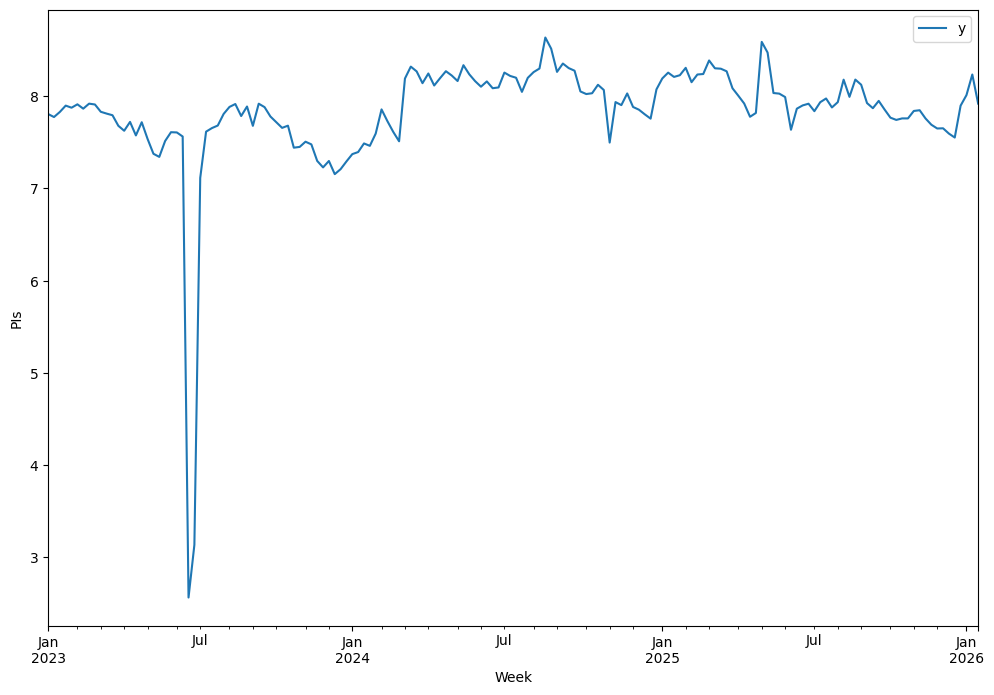

15:44:38 - cmdstanpy - INFO - Chain [1] start processing
15:44:38 - cmdstanpy - INFO - Chain [1] done processing


          ds         yhat  yhat_lower   yhat_upper
0 2023-01-02  2502.957501  914.568704  6236.935015
1 2023-01-09  1673.985147  653.895760  4373.748018
2 2023-01-16  1710.430384  681.850513  4284.826524
3 2023-01-23  1699.620317  668.264751  4480.824965
4 2023-01-30  1791.995309  729.770065  4510.735279
Mean Absolute Percentage Error (MAPE): 57.86%


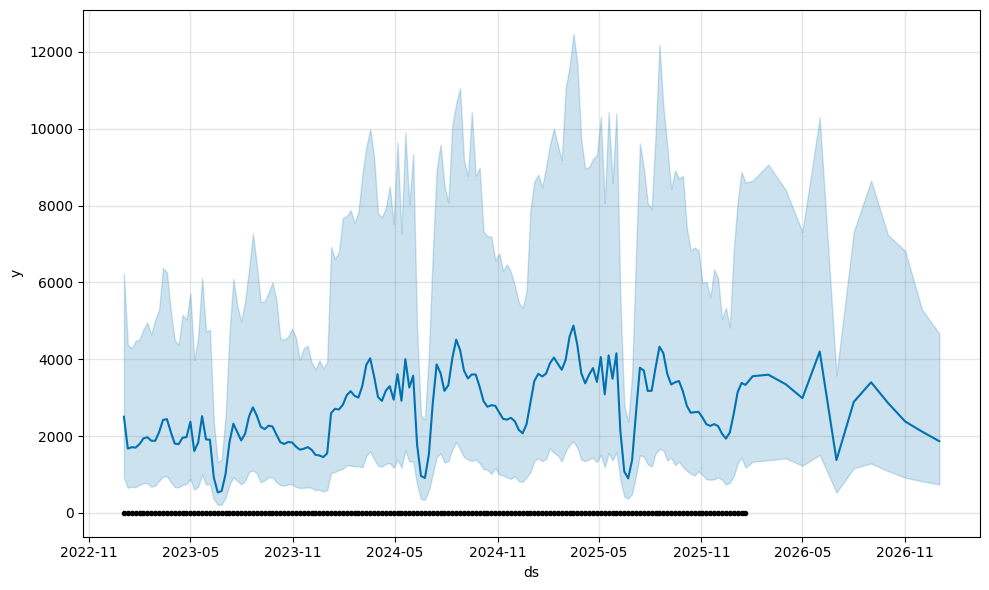

In [117]:


# The 'week_start' column remains unchanged
print(PI_sorted.dtypes)
#print(QA_sorted)

PI_log = PI_sorted.drop(columns = ['y']) 

PI_log = PI_log.rename(columns={'log_y': 'y'})

PI_log_sorted = PI_log.sort_values(by='ds', ascending=True)
ax = PI_log_sorted.set_index('ds').plot(figsize=(12, 8))
ax.set_ylabel('PIs')
ax.set_xlabel('Week')
plt.show()

# set the uncertainty interval to 95% 
PI_log_model = Prophet(interval_width=0.95)
PI_log_model.add_country_holidays(country_name='UK') # Example for UK holidays
PI_log_model.fit(PI_log_sorted)
PI_log_future_dates = PI_log_model.make_future_dataframe(periods=12, freq='MS')
PI_log_future_dates.head()
PI_log_forecast = PI_log_model.predict(PI_log_future_dates)
PI_log_forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].head()

# Inverse transform the predictions back to the original scale
# Apply np.exp() to each column individually

# Overwrite the existing columns with the inverse transformed values
PI_log_forecast['yhat'] = np.exp(PI_log_forecast['yhat'])
PI_log_forecast['yhat_lower'] = np.exp(PI_log_forecast['yhat_lower'])
PI_log_forecast['yhat_upper'] = np.exp(PI_log_forecast['yhat_upper'])

# Now, select and display the DataFrame in the exact format as required
fin_forecast_df = PI_log_forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']]

print(fin_forecast_df.head())

PI_log_model.plot(fin_forecast_df, uncertainty=True)

from sklearn.metrics import mean_absolute_percentage_error
comp_df = pd.merge(PI_sorted, fin_forecast_df, on='ds', how='inner')
actuals = comp_df['y']
predictions = comp_df['yhat']

# Scikit-learn returns a relative value (0.0 to 1.0), so we multiply by 100 for percentage
mape_on_actual_scale = mean_absolute_percentage_error(actuals, predictions) * 100

print(f"Mean Absolute Percentage Error (MAPE): {mape_on_actual_scale:.2f}%")

In [18]:
import pandas as pd
import holidays

# 1. Get UK bank holidays using the holidays package
# Note: The 'holidays' library is dynamic and provides correct dates, including substitute days.
uk_holidays = holidays.country_holidays('GB', years=range(2023, 2027))

# Convert the library output to a DataFrame suitable for Prophet
# We set a small window of 0 or 1 day for standard bank holidays
holidays_df = pd.DataFrame(list(uk_holidays.items()), columns=['ds', 'holiday'])
holidays_df['ds'] = pd.to_datetime(holidays_df['ds'])
holidays_df['lower_window'] = 0
holidays_df['upper_window'] = 1 # Effect likely limited to the day after

# 2. Add the specific, non-recurring 2024 events (One-Offs)
# These dates are specific to your website's data and are treated as unique historical anomalies.
one_off_events_2024 = pd.DataFrame([
    # May 2023 Event Window (1-day event with a large 10-day window to cover the multi-day spike)
    {'holiday': 'OneOff_Jan_Event_2026', 'ds': pd.to_datetime('2026-01-19'), 'lower_window': -10, 'upper_window': 10},
    
    # July 2023 Event Window (1-day event with a large 10-day window)
    {'holiday': 'OneOff_June_Event_2023', 'ds': pd.to_datetime('2023-06-26'), 'lower_window': -10, 'upper_window': 10},
    # Aug 2023 Event Window (1-day event with a large 10-day window)
   # {'holiday': 'OneOff_Jul_Event_2023', 'ds': pd.to_datetime('2023-08-21'), 'lower_window': -10, 'upper_window': 10},
])

# Concatenate all events and sort by date
holidays_df = pd.concat([holidays_df, one_off_events_2024]).sort_values('ds').reset_index(drop=True)

# Define columns as strings for Prophet
holidays_df['holiday'] = holidays_df['holiday'].astype(str)

print(holidays_df)


           ds                    holiday  lower_window  upper_window
0  2023-01-01             New Year's Day             0             1
1  2023-01-02  New Year's Day (observed)             0             1
2  2023-04-07                Good Friday             0             1
3  2023-05-01                    May Day             0             1
4  2023-05-08  Coronation of Charles III             0             1
5  2023-05-29        Spring Bank Holiday             0             1
6  2023-06-26     OneOff_June_Event_2023           -10            10
7  2023-12-25              Christmas Day             0             1
8  2023-12-26                 Boxing Day             0             1
9  2024-01-01             New Year's Day             0             1
10 2024-03-29                Good Friday             0             1
11 2024-05-06                    May Day             0             1
12 2024-05-27        Spring Bank Holiday             0             1
13 2024-12-25              Christm

In [23]:
# Enter Redshift connection details
conn_args = {
    'host': 'cm-mks-helix-cluster-1.cgv0wa0jntot.us-west-2.redshift.amazonaws.com',
    'database': 'cm_sandbox_4',
    'port': 5439,
    'user': 'tribalvw',
    'password': 'R3$h!ft35263e3f!LxLc'
        }
# Establish connection
conn = redshift_connector.connect(**conn_args)

# Direct read (No S3 staging)
query = "SELECT * FROM tribal_vw.Models_Advanced_Forecasting"
input_df = pd.read_sql(query, conn) 
conn.close()
# Access the data directly as a Pandas DataFrame
data = input_df
polo = data[data['model'] == 'Polo']
polo['week_start'] = pd.to_datetime(polo['week_start'])
polo = polo.iloc[1:-1]
# Selected Model 0 for ID.3: Simple Model with data as it is and TREATING outliers with custom holidays
polo_df = data[data['model'] == 'Polo']
polo_df['week_start'] = pd.to_datetime(polo_df['week_start'])
polo_df = polo_df.sort_values(by='week_start', ascending=True)
polo_df = polo_df.iloc[1:-1]
polo_df = polo_df.replace (0, np.nan) 

import pandas as pd
import numpy as np

# List of numeric KPI columns
kpis = ['visits', 'quality_arrivals', 'purchase_intents', 'retailer_leads']

# Create a copy to preserve original if needed
polo_df_cleaned = polo_df.copy()

for col in kpis:
    # 1. Calculate IQR bounds
    Q1 = polo_df_cleaned[col].quantile(0.25)
    Q3 = polo_df_cleaned[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.2 * IQR
    upper_bound = Q3 + 1.2 * IQR
    
    # 2. Mask values outside bounds with NaN
    # The mask() function replaces values where the condition is True
    polo_df_cleaned[col] = polo_df_cleaned[col].mask(
        (polo_df_cleaned[col] < lower_bound) | (polo_df_cleaned[col] > upper_bound), 
        np.nan
    )


# Running the prophet model again on cleaned data
polo_df = polo_df_cleaned.copy()
# Model 0: Simple Model with data as it is and NOT replacing outliers with NANs or custom holidays

# 1. Data Preparation
polo_df['ds'] = pd.to_datetime(polo_df['week_start'])
kpis = ['visits', 'quality_arrivals', 'purchase_intents', 'retailer_leads']



In [24]:
# Apply Log Transformation (log(1+x)) for all KPIs
for kpi in kpis:
    polo_df[f'log_{kpi}'] = np.log1p(polo_df[kpi])

# 2. Iterative Model Training and Full Timeline Forecasting
final_forecasts = []
mape_scores = {}

for kpi in kpis:
    print(f"Processing model for: {kpi}")
    
    # Initialize Model with UK Holidays
    m =  Prophet(holidays=holidays_df, seasonality_mode='additive')
    #m.add_country_holidays(country_name='UK')
    
    # Fit on all available historical data (up to Jan 19, 2026)
    m.fit(polo_df[['ds', f'log_{kpi}']].rename(columns={f'log_{kpi}': 'y'}))
    
    # 3. Create a dataframe covering BOTH History and 3 Months Future
    # 'periods=48' 48 weeks forward from current date
    full_timeline_df = m.make_future_dataframe(periods=48, freq='W-MON')
    
    # Generate Predictions for the entire period (Dec 2022 to May 2026)
    forecast = m.predict(full_timeline_df)
    
    # 4. Inverse Transformation (e^y - 1) back to original scale
    for col in ['yhat', 'yhat_lower', 'yhat_upper']:
        forecast[col] = np.expm1(forecast[col])
    
    # 5. Calculate MAPE (on historical scale only)
    # Join historical actuals with the corresponding historical predictions
    performance_df = forecast.set_index('ds').join(polo_df.set_index('ds')[[kpi]], how='inner')
    mape = np.mean(np.abs((performance_df[kpi] - performance_df['yhat']) / performance_df[kpi])) * 100
    mape_scores[kpi] = mape
    # Formatting the output for Rivery/Export
    forecast = forecast.rename(columns={'ds': 'week_start'})
    polo_df['week_start'] = pd.to_datetime(polo_df['week_start'])
    # MERGE ACTUALS: Join the original KPI column from polo_df
    # ID3_df must have 'week_start' and the KPI column (e.g., 'visits')
    forecast_with_actuals = forecast.merge(
        polo[['week_start', kpi]], 
        on='week_start', 
        how='left'
    )

   # Store the full forecast for plotting
    # final_forecasts[kpi] = forecast
    
    # Select columns and rename the KPI column (e.g., 'visits') to 'actual'
    forecast_clean = forecast_with_actuals[['week_start', 'yhat', 'yhat_lower', 'yhat_upper', kpi]].copy()
    forecast_clean = forecast_clean.rename(columns={kpi: 'actual'})
    forecast_clean['KPI'] = kpi
    final_forecasts.append(forecast_clean)

   # 5. Final Output DataFrame
final_output_df = pd.concat(final_forecasts, ignore_index=True)
# final_output_df = final_output_df[final_output_df['week_start'] >= '2026-01-19']

# 6. Output MAPE Results
print("\n--- Model Performance (MAPE) ---")
for kpi, score in mape_scores.items():
    print(f"{kpi}: {score:.2f}%")


11:13:42 - cmdstanpy - INFO - Chain [1] start processing


Processing model for: visits


11:13:42 - cmdstanpy - INFO - Chain [1] done processing
11:13:42 - cmdstanpy - INFO - Chain [1] start processing


Processing model for: quality_arrivals


11:13:42 - cmdstanpy - INFO - Chain [1] done processing
11:13:43 - cmdstanpy - INFO - Chain [1] start processing


Processing model for: purchase_intents


11:13:43 - cmdstanpy - INFO - Chain [1] done processing
11:13:43 - cmdstanpy - INFO - Chain [1] start processing


Processing model for: retailer_leads


11:13:43 - cmdstanpy - INFO - Chain [1] done processing



--- Model Performance (MAPE) ---
visits: 5.42%
quality_arrivals: 5.20%
purchase_intents: 10.26%
retailer_leads: 22.06%


In [22]:



# Separate DataFrames for each KPI starting 19 Jan 2026a
polo_visits_forecast = final_output_df[final_output_df['KPI'] == 'visits'].copy()
polo_purchase_intents_forecast = final_output_df[final_output_df['KPI'] == 'purchase_intents'].copy()
polo_quality_arrivals_forecast = final_output_df[final_output_df['KPI'] == 'quality_arrivals'].copy()
polo_retailer_leads_forecast = final_output_df[final_output_df['KPI'] == 'retailer_leads'].copy()

# Optional: Remove the 'KPI' column for a clean output for each
polo_visits_forecast.drop(columns=['KPI'], inplace=True)
polo_purchase_intents_forecast.drop(columns=['KPI'], inplace=True)
polo_quality_arrivals_forecast.drop(columns=['KPI'], inplace=True)
polo_retailer_leads_forecast.drop(columns=['KPI'], inplace=True)

# Select relevant columns for final output/plotting
polo_visits_forecast = polo_visits_forecast[['week_start', 'yhat', 'yhat_lower', 'yhat_upper', 'actual']]
forecast_v = polo_visits_forecast.copy()
polo_purchase_intents_forecast = polo_purchase_intents_forecast[['week_start', 'yhat', 'yhat_lower', 'yhat_upper', 'actual']]
forecast_pi = polo_purchase_intents_forecast.copy()
polo_quality_arrivals_forecast = polo_quality_arrivals_forecast[['week_start', 'yhat', 'yhat_lower', 'yhat_upper', 'actual']]
forecast_qa = polo_quality_arrivals_forecast.copy()
polo_retailer_leads_forecast = polo_retailer_leads_forecast[['week_start', 'yhat', 'yhat_lower', 'yhat_upper', 'actual']]
forecast_rl = polo_retailer_leads_forecast.copy()

# 1. CLEANING 
forecast_v.columns = [
    col.replace(' ', '_')
       .replace('(', '')
       .replace(')', '')
       .replace("'", "")
       .replace('-', '_') 
    for col in forecast_v.columns
]
# Select only what you need
target_cols = ['week_start', 'yhat', 'yhat_lower', 'yhat_upper', 'actual']
forecast_cleaned_v = forecast_v[target_cols].copy()

# 1a. CLEANING 
forecast_pi.columns = [
    col.replace(' ', '_')
       .replace('(', '')
       .replace(')', '')
       .replace("'", "")
       .replace('-', '_') 
    for col in forecast_pi.columns
]
# Select only what you need
target_cols = ['week_start', 'yhat', 'yhat_lower', 'yhat_upper', 'actual']
forecast_cleaned_pi = forecast_pi[target_cols].copy()

# 1b. CLEANING 
forecast_qa.columns = [
    col.replace(' ', '_')
       .replace('(', '')
       .replace(')', '')
       .replace("'", "")
       .replace('-', '_') 
    for col in forecast_qa.columns
]

# Select only what you need
target_cols = ['week_start', 'yhat', 'yhat_lower', 'yhat_upper', 'actual']
forecast_cleaned_qa = forecast_qa[target_cols].copy()

# 1c. CLEANING 
forecast_rl.columns = [
    col.replace(' ', '_')
       .replace('(', '')
       .replace(')', '')
       .replace("'", "")
       .replace('-', '_') 
    for col in forecast_rl.columns
]

# Select only what you need
target_cols = ['week_start', 'yhat', 'yhat_lower', 'yhat_upper', 'actual']
forecast_cleaned_rl = forecast_rl[target_cols].copy()

import time

# 2. DATABASE OPERATIONS
try:
    conn = redshift_connector.connect(**conn_args)
    conn.autocommit = True 
    cursor = conn.cursor()

    cols_definition = "week_start TIMESTAMP, yhat FLOAT, yhat_lower FLOAT, yhat_upper FLOAT, actual FLOAT"

    # --- STEP 1: DROP, WAIT, AND CREATE TABLES ---
    tables = {
        "af_tribal.m_polo_Forecast_Visits": forecast_cleaned_v,
        "af_tribal.m_polo_Forecast_PIs": forecast_cleaned_pi,
        "af_tribal.m_polo_Forecast_QAs": forecast_cleaned_qa,
        "af_tribal.m_polo_Forecast_RLs": forecast_cleaned_rl
    }

    for table_name in tables.keys():
        cursor.execute(f"DROP TABLE IF EXISTS {table_name};")
        time.sleep(3) # Wait for Redshift catalog update
        cursor.execute(f"CREATE TABLE {table_name} ({cols_definition});")
        print(f"Table {table_name} created successfully.")
    
    conn.commit()

    # --- STEP 2: PREPARE AND INSERT DATA INDIVIDUALLY ---
    
    # A. Insert Visits
    print("Inserting data into polo_Forecast_Visits...")
    df_v = forecast_cleaned_v.where(pd.notna(forecast_cleaned_v), None)
    df_v['week_start'] = pd.to_datetime(df_v['week_start']).dt.strftime('%Y-%m-%d %H:%M:%S')
    tuples_v = [tuple(x) for x in df_v.to_numpy()]
    sql_v = f"INSERT INTO af_tribal.m_polo_Forecast_Visits (week_start, yhat, yhat_lower, yhat_upper, actual) VALUES (%s, %s, %s, %s, %s)"
    cursor.executemany(sql_v, tuples_v)
    conn.commit()

    # B. Insert PIs
    print("Inserting data into polo_Forecast_PIs...")
    df_pi = forecast_cleaned_pi.where(pd.notna(forecast_cleaned_pi), None)
    df_pi['week_start'] = pd.to_datetime(df_pi['week_start']).dt.strftime('%Y-%m-%d %H:%M:%S')
    tuples_pi = [tuple(x) for x in df_pi.to_numpy()]
    sql_pi = f"INSERT INTO af_tribal.m_polo_Forecast_PIs (week_start, yhat, yhat_lower, yhat_upper, actual) VALUES (%s, %s, %s, %s, %s)"
    cursor.executemany(sql_pi, tuples_pi)
    conn.commit()

    # C. Insert QAs
    print("Inserting data into polo_Forecast_QAs...")
    df_qa = forecast_cleaned_qa.where(pd.notna(forecast_cleaned_qa), None)
    df_qa['week_start'] = pd.to_datetime(df_qa['week_start']).dt.strftime('%Y-%m-%d %H:%M:%S')
    tuples_qa = [tuple(x) for x in df_qa.to_numpy()]
    sql_qa = f"INSERT INTO af_tribal.m_polo_Forecast_QAs (week_start, yhat, yhat_lower, yhat_upper, actual) VALUES (%s, %s, %s, %s, %s)"
    cursor.executemany(sql_qa, tuples_qa)
    conn.commit()

    # C. Insert RLs
    print("Inserting data into polo_Forecast_RLs...")
    df_rl = forecast_cleaned_rl.where(pd.notna(forecast_cleaned_rl), None)
    df_rl['week_start'] = pd.to_datetime(df_rl['week_start']).dt.strftime('%Y-%m-%d %H:%M:%S')
    tuples_rl = [tuple(x) for x in df_rl.to_numpy()]
    sql_rl = f"INSERT INTO af_tribal.m_polo_Forecast_RLs (week_start, yhat, yhat_lower, yhat_upper, actual) VALUES (%s, %s, %s, %s, %s)"
    cursor.executemany(sql_rl, tuples_rl)
    conn.commit()

    print("Success: All 4 KPI forecasts pushed to Redshift.")

except Exception as e:
    print(f"Error occurred: {e}")
    raise 
finally:
    cursor.close()
    conn.close()
      


Table public.m_polo_Forecast_Visits created successfully.
Table public.m_polo_Forecast_PIs created successfully.
Table public.m_polo_Forecast_QAs created successfully.
Table public.m_polo_Forecast_RLs created successfully.
Inserting data into polo_Forecast_Visits...
Inserting data into polo_Forecast_PIs...
Inserting data into polo_Forecast_QAs...
Inserting data into polo_Forecast_RLs...
Success: All 4 KPI forecasts pushed to Redshift.
